# Initialisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Chargement du df

In [2]:
df = pd.read_csv("../data/processed/parcoursup_2026_enriched_rag.csv")

In [3]:
df

,session,id_etablissement,name_etablissement,type_etablissement,type_formation,name_formation,mentions_specialites,apprentissage,internat,amenagement,...,frais_scolarite_boursiers,langues_options,nb_places,formation_ouverte_boursiers,diplome_controle_par_etat,formation_selective,epreuves_selection,frais_candidature,frais_candidature_boursiers,rag_document
0,2026,0212108C,Polytech Dijon (21),Publics,Formations des écoles d'ingénieurs,Formation d'ingénieur Bac + 5 - Bac général,Formation d'ingénieur Bac + 5,NaN,NaN,"Enseignement en présentiel,Formations avec amé...",...,0,Langue vivante 1 :\nAnglais\nLangue vivante 2 ...,120.0,1.0,1.0,1.0,Tous les candidats inscrits au concours seront...,"60,00 €","0,00 €",Nom de la formation : Formation d'ingénieur Ba...
1,2026,0492226D,Polytech Angers (49),Publics,Formations des écoles d'ingénieurs,Formation d'ingénieur Bac + 5 - Bac général,Formation d'ingénieur Bac + 5,NaN,NaN,"Enseignement en présentiel,Formations avec amé...",...,0,Langue vivante 1 :\nAnglais\nLangue vivante 2 ...,95.0,1.0,1.0,1.0,Tous les candidats inscrits au concours seront...,"60,00 €","0,00 €",Nom de la formation : Formation d'ingénieur Ba...
2,2026,0542259M,EEIGM Nancy - Groupe INP (54),Publics,Formations des écoles d'ingénieurs,Formation d'ingénieur Bac + 5 - Bac général,Formation d'ingénieur Bac + 5,NaN,NaN,"Enseignement en présentiel,Formations avec amé...",...,0,Langue vivante 1 :\nAnglais\nLangue vivante 2 ...,82.0,1.0,1.0,1.0,Tous les candidats inscrits au concours seront...,"60,00 €","0,00 €",Nom de la formation : Formation d'ingénieur Ba...
3,2026,0542307P,ENSGSI Nancy - Groupe INP (54),Publics,Formations des écoles d'ingénieurs,Formation d'ingénieur Bac + 5 - Bac général,Formation d'ingénieur Bac + 5,NaN,NaN,"Enseignement en présentiel,Formations avec amé...",...,0,Langue vivante 1 :\nAnglais\nLangue vivante 2 ...,50.0,1.0,1.0,1.0,Tous les candidats inscrits au concours seront...,"60,00 €","0,00 €",Nom de la formation : Formation d'ingénieur Ba...
4,2026,0597060D,IMT Nord Europe (Villeneuve-d'Ascq - 59),Publics,Formations des écoles d'ingénieurs,Formation d'ingénieur Bac + 5 - Bac général,Formation d'ingénieur Bac + 5,NaN,NaN,"Enseignement en présentiel,Formations avec amé...",...,0,Langue vivante 1 :\nAnglais\nLangue vivante 2 ...,160.0,1.0,1.0,1.0,Tous les candidats inscrits au concours seront...,"60,00 €","0,00 €",Nom de la formation : Formation d'ingénieur Ba...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24053,2026,0110670U,Lycée Beausejour (Narbonne - 11),Privés en contrat avec l’Etat / EESC,"Formations diplômantes du travail social,BTS -...",BTS - Services - Economie sociale familiale,BTS - Economie sociale familiale,NaN,NaN,Enseignement en présentiel,...,NaN,NaN,35.0,1.0,1.0,1.0,NaN,NaN,NaN,Nom de la formation : BTS - Services - Economi...
24054,2026,0110983J,I.U.T de Perpignan (Site de Narbonne) (11),Publics,BUT,BUT - Carrières juridiques,"BUT - Entreprise et Association,BUT - Patrimoi...",NaN,NaN,"Enseignement en présentiel,Formations avec amé...",...,NaN,NaN,84.0,1.0,1.0,1.0,NaN,NaN,NaN,Nom de la formation : BUT - Carrières juridiqu...
24055,2026,0120006S,Lycée La Découverte (Decazeville - 12),Publics,BTS - BTSA - BTSM,BTS - Production - Europlastics et composites ...,BTS - Europlastics et composites à référentiel...,NaN,NaN,Enseignement en présentiel,...,NaN,NaN,7.0,1.0,1.0,1.0,NaN,NaN,NaN,Nom de la formation : BTS - Production - Europ...
24056,2026,0120012Y,Lycée Jean Vigo (Millau - 12),Publics,BTS - BTSA - BTSM,BTS - Services - Gestion de la PME,BTS - Gestion de la PME,NaN,NaN,Enseignement en présentiel,...,NaN,NaN,9.0,1.0,1.0,1.0,NaN,NaN,NaN,Nom de la formation : BTS - Services - Gestion...


## Exploration du df

### Création d'une copie du df

In [9]:
df_copy = df.copy()

### Création d'une colonne int pour la longueur des caractères

In [10]:
df_copy["len_char"] = df_copy["rag_document"].astype(str).str.len()
df_copy["len_char"]

0        5265
1        5268
2        4344
3        4236
4        4426
         ... 
24053     353
24054     316
24055     459
24056     263
24057     302
Name: len_char, Length: 24058, dtype: int64

In [ ]:
print(int(df_copy["rag_document"].astype(str).str.len().max()))

6857


In [ ]:
df_copy["rag_document"].astype(str).str.len().mean()

np.float64(848.4944301271926)

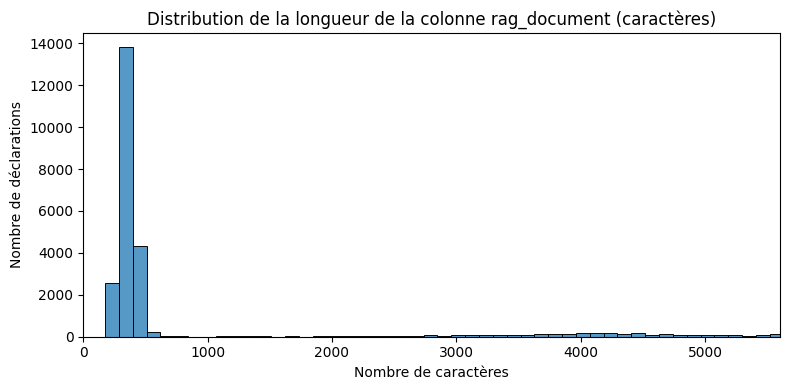

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(df_copy["len_char"], bins=60, kde=False)
plt.title("Distribution de la longueur de la colonne rag_document (caractères)")
plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre de déclarations")
plt.xlim(0, df_copy["len_char"].quantile(0.99))
plt.tight_layout()
plt.show()


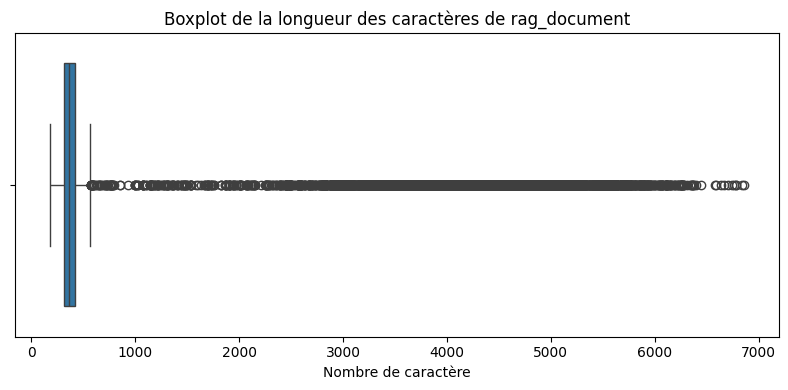

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_copy["len_char"])
plt.title("Boxplot de la longueur des caractères de rag_document")
plt.xlabel("Nombre de caractère")
plt.tight_layout()
plt.show()

In [14]:
df_copy["len_char"].describe()

count    24058.00000
mean       848.49443
std       1336.14905
min        176.00000
25%        319.00000
50%        361.00000
75%        420.00000
max       6857.00000
Name: len_char, dtype: float64

In [15]:
df_copy.sort_values("len_char", ascending=False)[
    ["name_formation", "len_char", "rag_document"]
].head(3)

,name_formation,len_char,rag_document
13538,Licence - Psychologie,6857,Nom de la formation : Licence - Psychologie\n\...
9740,Licence - Psychologie - Accès Santé (LAS),6837,Nom de la formation : Licence - Psychologie - ...
21343,Licence - Sciences et Techniques des Activités...,6784,Nom de la formation : Licence - Sciences et Te...


In [17]:
(df_copy["len_char"] > 1000).sum()

np.int64(3124)